### 第8章 形态学操作
- 形态学主要从图像内提取分量信息，对于表达和描绘图像的形状具有重要意义，通常是图像最本质的形状特征。
#### 8.1 腐蚀
- 腐蚀能够将图像的边界点消除，使图像沿着边界向内收缩，也可以将小于指定结构体元素的部分去除
- `dst = cv2.erode(src, kernel[, anchor[, iterations[, borderType[, borderValue]]]])`
    - dst 是腐蚀后输出的目标图像，和原始图像具有相同的类型和大小
    - src 是需要进行腐蚀的原始图像，通道时可以是任意的，但图像深度必须是CV_8U, CV_16U, CV_16S, CV_32F, CV_64F中的一种
    - kernel 是腐蚀操作所采用的结构类型，可以自定义或者通过`cv2.getStructuringElement()`生成
    - anchor 代表element中锚点的位置，默认为`(-1, -1)`，表示在核的中心位置
    - iterations 是腐蚀操作的迭代次数，默认为1
    - borderType 代表边界样式，一般采用默认值`BORDER_CONSTANT`
    - borderValue 是边界值，一般采用默认值。C++中函数`morphologyDefaultBorderValue()`返回腐蚀和膨胀的边界值，Python中不支持该函数


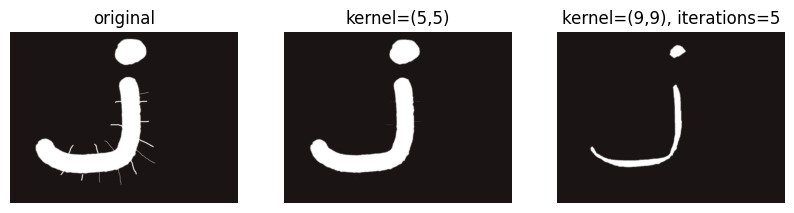

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import numpy as np

o = cv2.imread("erode.bmp", cv2.IMREAD_UNCHANGED)
kernel1 = np.ones((5, 5), np.uint8)
erosion1 = cv2.erode(o, kernel1, iterations=1)

# kernel2 = np.ones((5, 5), np.uint8)
kernel2 = np.ones((9, 9), np.uint8)
erosion2 = cv2.erode(o, kernel2, iterations=5)

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
erosion1 = cv2.cvtColor(erosion1, cv2.COLOR_BGR2RGB)
erosion2 = cv2.cvtColor(erosion2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.subplot(131)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(132)
plt.imshow(erosion1)
plt.title("kernel=(5,5)")
plt.axis("off")
plt.subplot(133)
plt.imshow(erosion2)
plt.title("kernel=(9,9), iterations=5")
plt.axis("off")
plt.show()

#### 8.2 膨胀
- 膨胀将与当前对象接触到的背景点合并到当前对象内，实现将图像的边界点向外扩张
- `dst = cv2.dilate(src, kernel[, anchor[, iterations[, borderType[, borderValue]]]])`
    - dst 是膨胀后输出的目标图像，和原始图像具有相同的类型和大小
    - src 是需要进行膨胀的原始图像，通道时可以是任意的，但图像深度必须是CV_8U, CV_16U, CV_16S, CV_32F, CV_64F中的一种
    - kernel 是膨胀操作所采用的结构类型，可以自定义或者通过`cv2.getStructuringElement()`生成
    - anchor、iterations、borderType 和 borderValue 与 `cv2.erode()` 内相应的参数含义一致

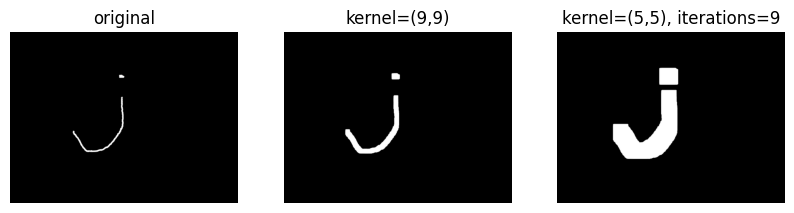

In [4]:
import cv2
import numpy as np
o = cv2.imread("dilation.bmp", cv2.IMREAD_UNCHANGED)
kernel1 = np.ones((9, 9), np.uint8)
dilation1 = cv2.dilate(o, kernel1)
kernel2 = np.ones((5,5), np.uint8)
dilation2 = cv2.dilate(o, kernel2, iterations=9)

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
dilation1 = cv2.cvtColor(dilation1, cv2.COLOR_BGR2RGB)
dilation2 = cv2.cvtColor(dilation2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.subplot(131)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(132)
plt.imshow(dilation1)
plt.title("kernel=(9,9)")
plt.axis("off")
plt.subplot(133)
plt.imshow(dilation2)
plt.title("kernel=(5,5), iterations=9")
plt.axis("off")
plt.show()

#### 8.3 通用形态学函数
- `dst = cv2.morphologyEx(src, op, kernel[, anchor[, iterations[, borderType[, borderValue]]]])`
    - dst 是形态学处理后输出的目标图像，和原始图像具有相同的类型和大小
    - src 是需要进行形态学操作的原始图像，通道时可以是任意的，但图像深度必须是CV_8U, CV_16U, CV_16S, CV_32F, CV_64F中的一种
    - op 代表操作类型，含义如下：
        - `cv2.MORPH_ERODE`: 腐蚀操作
        - `cv2.MORPH_DILATE`: 膨胀操作
        - `cv2.MORPH_OPEN`: 开运算，先腐蚀后膨胀
        - `cv2.MORPH_CLOSE`: 闭运算，先膨胀后腐蚀
        - `cv2.MORPH_GRADIENT`: 形态学梯度运算，膨胀图减去腐蚀图
        - `cv2.MORPH_TOPHAT`: 顶帽运算，原始图像减去开运算
        - `cv2.MORPH_BLACKHAT`: 黑帽运算，闭运算减去原始图像
        - `cv2.MORPH_HITMISS`: 击中击不中前景背景腐蚀运算的交集，仅支持CV_8UC1二进制图像
    - kernel、anchor、iterations、borderType 和 borderValue 与 `cv2.erode()` 内相应的参数含义一致

##### 8.3.1 开运算
- 先将图像腐蚀，再对腐蚀结果进行膨胀，可以用于去噪、计数等

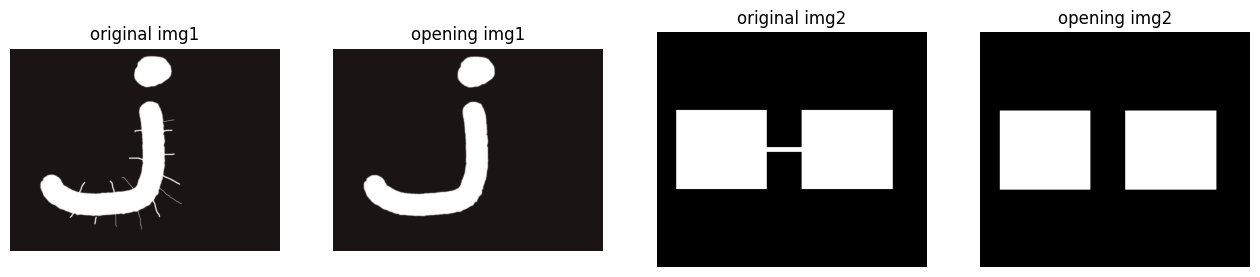

In [ ]:
import cv2
import numpy as np
img1 = cv2.imread("opening.bmp")
img2 = cv2.imread("opening2.bmp")
k = np.ones((10, 10), np.uint8)
r1 = cv2.morphologyEx(img1, cv2.MORPH_OPEN, k)
r2 = cv2.morphologyEx(img2, cv2.MORPH_OPEN, k)

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
r1 = cv2.cvtColor(r1, cv2.COLOR_BGR2RGB)
r2 = cv2.cvtColor(r2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 6))
plt.subplot(141)
plt.imshow(img1)
plt.title("original img1")
plt.axis("off")
plt.subplot(142)
plt.imshow(r1)
plt.title("opening img1")
plt.axis("off")
plt.subplot(143)
plt.imshow(img2)
plt.title("original img2")
plt.axis("off")
plt.subplot(144)
plt.imshow(r2)
plt.title("opening img2")
plt.axis("off")
plt.show()

##### 8.3.2 闭运算
- 闭运算是先膨胀、后腐蚀的运算，有助于关闭前景物体内部的小孔，或去除物体上的小黑点，还可以将不同的前景图像进行连接

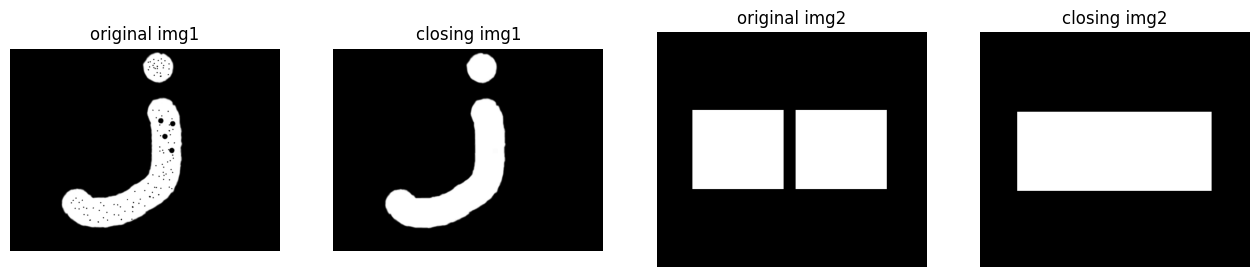

In [ ]:
import cv2
import numpy as np
img1 = cv2.imread("closing.bmp")
img2 = cv2.imread("closing2.bmp")
k = np.ones((10, 10), np.uint8)
r1 = cv2.morphologyEx(img1, cv2.MORPH_CLOSE, k, iterations=1)
r2  =cv2.morphologyEx(img2, cv2.MORPH_CLOSE, k, iterations=3)

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
r1 = cv2.cvtColor(r1, cv2.COLOR_BGR2RGB)
r2 = cv2.cvtColor(r2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 6))
plt.subplot(141)
plt.imshow(img1)
plt.title("original img1")
plt.axis("off")
plt.subplot(142)
plt.imshow(r1)
plt.title("closing img1")
plt.axis("off")
plt.subplot(143)
plt.imshow(img2)
plt.title("original img2")
plt.axis("off")
plt.subplot(144)
plt.imshow(r2)
plt.title("closing img2")
plt.axis("off")
plt.show()

##### 8.3.3 形态学梯度运算
- 形态学梯度运算是用膨胀图像减去腐蚀图像的操作，可以获取原始图像中前景图像的边缘

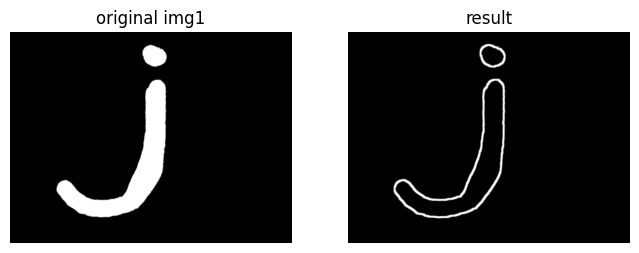

In [11]:
import cv2
import numpy as np
o = cv2.imread("gradient.bmp")
k = np.ones((5, 5), np.uint8)
r = cv2.morphologyEx(o, cv2.MORPH_GRADIENT, k)

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
r = cv2.cvtColor(r, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(o)
plt.title("original img1")
plt.axis("off")
plt.subplot(122)
plt.imshow(r)
plt.title("result")
plt.axis("off")

plt.show()

##### 8.3.4 礼帽运算
- 礼帽运算是用原始图像减去开运算图像，能够获取图像的噪声信息，或者得到比原始图像的边缘更亮的边缘信息


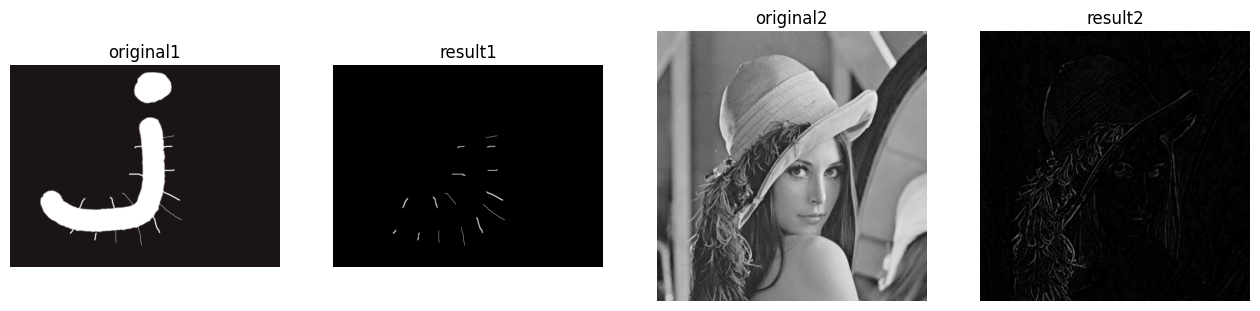

In [ ]:
import cv2
import numpy as np
img1 = cv2.imread("tophat.bmp")
img2 = cv2.imread("lena.bmp")
k = np.ones((5, 5), np.uint8)
r1 = cv2.morphologyEx(img1, cv2.MORPH_TOPHAT, k)
r2 = cv2.morphologyEx(img2, cv2.MORPH_TOPHAT, k)

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
r1 = cv2.cvtColor(r1, cv2.COLOR_BGR2RGB)
r2 = cv2.cvtColor(r2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 6))
plt.subplot(141)
plt.imshow(img1)
plt.title("original1")
plt.axis("off")
plt.subplot(142)
plt.imshow(r1)
plt.title("result1")
plt.axis("off")
plt.subplot(143)
plt.imshow(img2)
plt.title("original2")
plt.axis("off")
plt.subplot(144)
plt.imshow(r2)
plt.title("result2")
plt.axis("off")
plt.show()

##### 8.3.5 黑帽运算
- 黑帽运算是用闭运算图像减去原始图像，能够获取图像内部的小孔，或前景色中的小黑点，或者得到比原始图像的边缘更暗的边缘部分


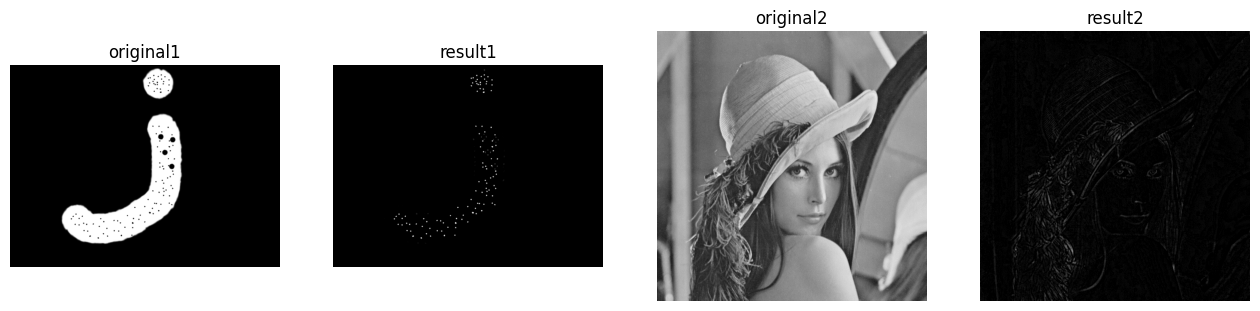

In [15]:
import cv2
import numpy as np
img1 = cv2.imread("blackhat.bmp")
img2 = cv2.imread("lena.bmp")
k = np.ones((5, 5), np.uint8)
r1 = cv2.morphologyEx(img1, cv2.MORPH_BLACKHAT, k)
r2 = cv2.morphologyEx(img2, cv2.MORPH_BLACKHAT, k)

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
r1 = cv2.cvtColor(r1, cv2.COLOR_BGR2RGB)
r2 = cv2.cvtColor(r2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 6))
plt.subplot(141)
plt.imshow(img1)
plt.title("original1")
plt.axis("off")
plt.subplot(142)
plt.imshow(r1)
plt.title("result1")
plt.axis("off")
plt.subplot(143)
plt.imshow(img2)
plt.title("original2")
plt.axis("off")
plt.subplot(144)
plt.imshow(r2)
plt.title("result2")
plt.axis("off")
plt.show()

#### 8.4 核函数
- `retval = cv2.getStructureingElement(shape, ksize[, anchor])` 该函数返回一个用于形态学操作的指定大小和形状的结构元素
    - shape 代表形状类型，取值如下：
        - `cv2.MORPH_RECT: 矩形结构元素，所有元素值都是1
        - `cv2.MORPH_CROSS: 十字形结构元素，对角线元素值都是1
        - `cv2.MORPH_ELLIPSE: 椭圆形结构元素
    - ksize 表示结构元素的大小
    - anchor 表示结构元素中的冒点位置，默认值`(-1, -1)`是形状的中心，只有十字形形状与锚点位置相关，在其他情况下，锚点仅用于形态学运算结果的调整


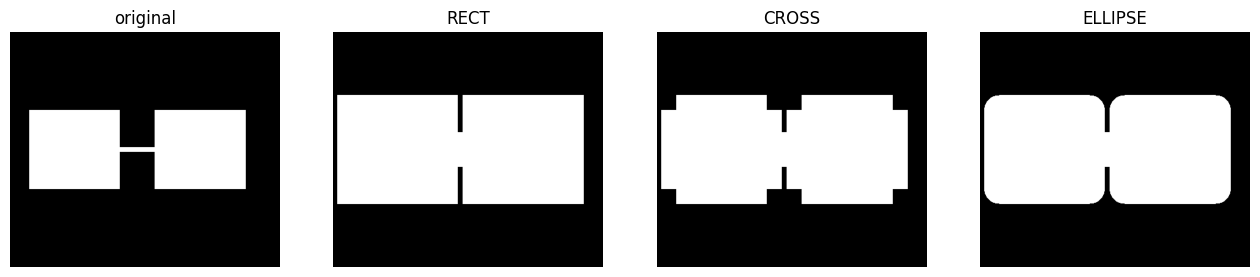

In [18]:
import cv2
o = cv2.imread("kernel.bmp", cv2.IMREAD_UNCHANGED)
kernel1 = cv2.getStructuringElement(cv2.MORPH_RECT, (51,51))
kernel2 = cv2.getStructuringElement(cv2.MORPH_CROSS,  (51,51))
kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,  (51,51))
dst1 = cv2.dilate(o, kernel1)
dst2 = cv2.dilate(o, kernel2)
dst3 = cv2.dilate(o, kernel3)

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
dst1 = cv2.cvtColor(dst1, cv2.COLOR_BGR2RGB)
dst2 = cv2.cvtColor(dst2, cv2.COLOR_BGR2RGB)
dst3 = cv2.cvtColor(dst3, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 6))
plt.subplot(141)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(142)
plt.imshow(dst1)
plt.title("RECT")
plt.axis("off")
plt.subplot(143)
plt.imshow(dst2)
plt.title("CROSS")
plt.axis("off")
plt.subplot(144)
plt.imshow(dst3)
plt.title("ELLIPSE")
plt.axis("off")
plt.show()